> **Chapter 12, Part 0** | Advanced lens. **Focus:** what graphs add to the Chapter 11 argument and which two bridges (time series, image) the rest of the chapter actually walks across.

# Why Graphs Deserve a Fractal Lens

Chapter 11 used pictures and time series to teach scale-sensitive descriptors. Most enterprise objects worth governing are graphs already: data lineage DAGs, entity-resolution match graphs, product hierarchies, microservice dependencies. The graph is not a metaphor here. It is the data structure those objects already live in. Box-counting still applies. It just lives on a different geometry.

This chapter walks across three bridges:

1. **Time series to graph** via the Lacasa visibility algorithm (12.2). Periodic series become regular graphs. Random series become exponential graphs. Fractal series become scale-free graphs whose degree exponent tracks the Hurst exponent.
2. **Image to graph** via box-covering on networks (12.3). The same reasoning that produced `d_B` from the Mandelbrot boundary in 11.1 produces a `d_B` from a network, with the same log-log fit and the same epistemic discipline.
3. **Governance to graph** via lineage and entity resolution (12.5 and 12.6). The 11.4 duplicate-cluster work is procedurally union-find; this chapter shows the same problem as a graph and adds descriptors the procedural form cannot expose.

## The bounded claim, restated

I am not claiming enterprise data is fractal. I am asking whether selected enterprise graphs show enough multi-scale structure that fractal descriptors become useful for stewardship triage. Where the test fails, this chapter says so. Where the test passes, this chapter explains what governance decision the measurement should improve.

## Outputs

- a clear answer to the question "why graphs after Chapter 11"
- a Karate-club teaser that previews the box and skeleton ideas
- a chapter-spanning assignment to anchor your own enterprise object across 12.0 through 12.7

## Supporting reading

- Song, C., Havlin, S., and Makse, H. A. (2005). Self-similarity of complex networks. *Nature* 433, 392-395. https://www.nature.com/articles/nature03248
- Skums, P., and Bunimovich, L. (2020). Graph fractal dimension and the structure of fractal networks. *Journal of Complex Networks* 8(4). https://pmc.ncbi.nlm.nih.gov/articles/PMC7673317/
- Hari, D. (2026). Static and Temporal Fractal Coupling Between Volatility and Trading Volume. *Zenodo*. https://doi.org/10.5281/zenodo.19611544

## Failure note

If you finish 12.0 and still cannot say which graph in your own work would benefit from a fractal lens, the chapter has failed. The descriptors are only useful where the object class is named first.

## How I would debug this

Pick one graph from your environment before reading 12.1. Write down its node type, edge type, and the boundary you currently use to decide if two records are the same entity. We will return to that example in 12.5 and 12.6.


nodes 34 edges 78


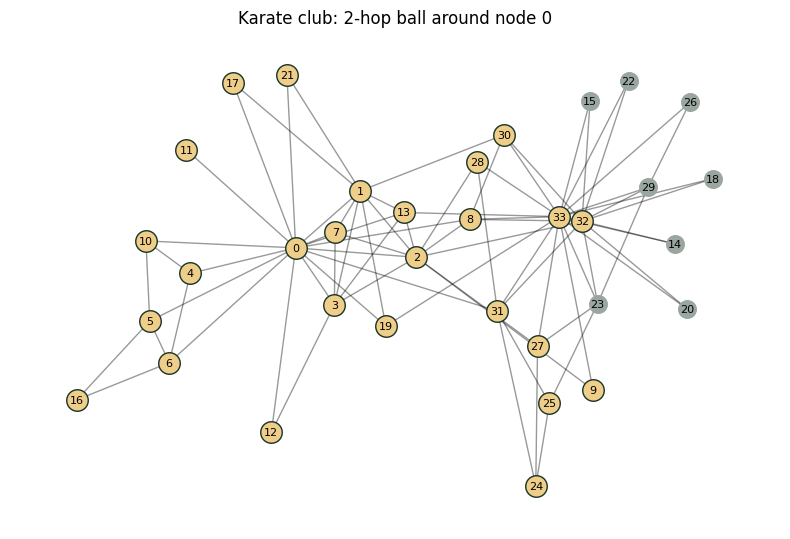

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

g = nx.karate_club_graph()
print("nodes", g.number_of_nodes(), "edges", g.number_of_edges())

center = 0
ball_radius = 2
ball = {center} | {n for n in nx.single_source_shortest_path_length(g, center, cutoff=ball_radius)}

pos = nx.spring_layout(g, seed=7)
plt.figure(figsize=(8, 5.5))
nx.draw_networkx_edges(g, pos, alpha=0.4)
nx.draw_networkx_nodes(g, pos, nodelist=list(g.nodes() - ball), node_color="#9aa6a0", node_size=160)
nx.draw_networkx_nodes(g, pos, nodelist=list(ball), node_color="#efce8a", node_size=240, edgecolors="#173326")
nx.draw_networkx_labels(g, pos, font_size=8)
plt.title(f"Karate club: {ball_radius}-hop ball around node {center}")
plt.axis("off")
plt.tight_layout()
plt.show()


The gold nodes form a **box** of radius 2 around node 0. That same idea, repeated at multiple radii and aggregated across the whole graph, is what 12.3 will use to estimate a network's box dimension. Hold on to the visual; the rest of the chapter formalizes it.

## Chapter assignment

Pick one graph in your environment. Lineage. Entity match. Knowledge. Microservice. Document the following before continuing:

1. node type and what each node represents
2. edge type and what an edge means in the operational sense
3. the boundary you currently use to decide where the graph ends or where two records are the same entity

We will return to your example in 12.5 (lineage) and 12.6 (entity resolution). Do not skip this step. Without a concrete object the rest of the chapter reads like decoration.
